In [ ]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("nudratabbas/global-company-layoffs-prediction-dataset")

# check where it is (codespaces / remote kernels)
print("Downloaded to:", path)
print("Files:", os.listdir(path))
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: /home/codespace/.cache/kagglehub/datasets/nudratabbas/global-company-layoffs-prediction-dataset/versions/1
Files: ['layoffs']
/home/codespace/.cache/kagglehub/datasets/nudratabbas/global-company-layoffs-prediction-dataset/versions/1/layoffs/data_dictionary.csv
/home/codespace/.cache/kagglehub/datasets/nudratabbas/global-company-layoffs-prediction-dataset/versions/1/layoffs/README.md
/home/codespace/.cache/kagglehub/datasets/nudratabbas/global-company-layoffs-prediction-dataset/versions/1/layoffs/train.csv
/home/codespace/.cache/kagglehub/datasets/nudratabbas/global-company-layoffs-prediction-dataset/versions/1/layoffs/test.csv


In [2]:
train_df = pd.read_csv(os.path.join(path, "layoffs/train.csv"))
test_df = pd.read_csv(os.path.join(path, "layoffs/test.csv"))

train_df.head()

,company,industry,country,funding_amount,employee_count,growth_rate,valuation,layoff_happened
0,Company_vrzD7Zhl,Real Estate,USA,917215428,53060,143.37,1.706021e+09,0
1,Company_3OJQGaHb,Automotive,Germany,3886088690,98556,177.24,1.869209e+10,0
2,Company_iChfXlEW,Real Estate,Germany,509868992,65992,58.26,3.079609e+09,1
3,Company_GBHyTQ2d,Logistics,UK,4180168950,38180,111.39,2.173688e+10,0
4,Company_cpOLkT6x,Tech,Japan,3031189942,56530,174.79,2.667447e+10,1


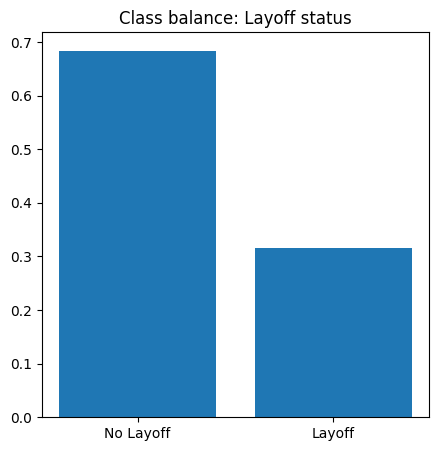

In [25]:
import matplotlib.pyplot as plt

counts = train_df["layoff_happened"].value_counts().sort_index()
proportions = counts / counts.sum()

plt.figure(figsize=(5, 5))
plt.bar(proportions.index, proportions.values)
plt.title("Class balance: Layoff status")
plt.xticks(proportions.index, ["No Layoff", "Layoff"])
plt.show()

In [ ]:
# stats for the firms with layoffs
laidoff_df = train_df[train_df["layoff_happened"] == 1]

# stats for the firms WITHOUT layoffs (no layoffs)
not_laidoff_df = train_df[train_df["layoff_happened"] == 0]



fmt_laidoff = (laidoff_df.drop("layoff_happened", axis=1).describe()
 .drop("count")
 .style.format({
     "funding_amount": "${:,.0f}",
     "valuation": "${:,.0f}",
     "employee_count": "{:,.0f}",
     "growth_rate": "{:.2f}%",
 })
)
fmt_not_laidoff = (not_laidoff_df.drop("layoff_happened", axis=1).describe()
 .drop("count")
 .style.format({
     "funding_amount": "${:,.0f}",
     "valuation": "${:,.0f}",
     "employee_count": "{:,.0f}",
     "growth_rate": "{:.2f}%",
 })
)

,funding_amount,employee_count,growth_rate,valuation
mean,"$2,456,185,540","50,599",52.58%,"$14,022,052,508"
std,"$1,431,094,812","28,464",75.17%,"$10,651,917,091"
min,"$1,298,162",21,-49.89%,"$2,362,655"
25%,"$1,206,407,434","25,548",-15.99%,"$5,633,695,135"
50%,"$2,449,680,129","50,790",40.67%,"$11,493,262,522"
75%,"$3,673,230,471","75,204",117.24%,"$20,444,087,737"
max,"$4,999,076,071","99,996",199.87%,"$49,326,422,072"


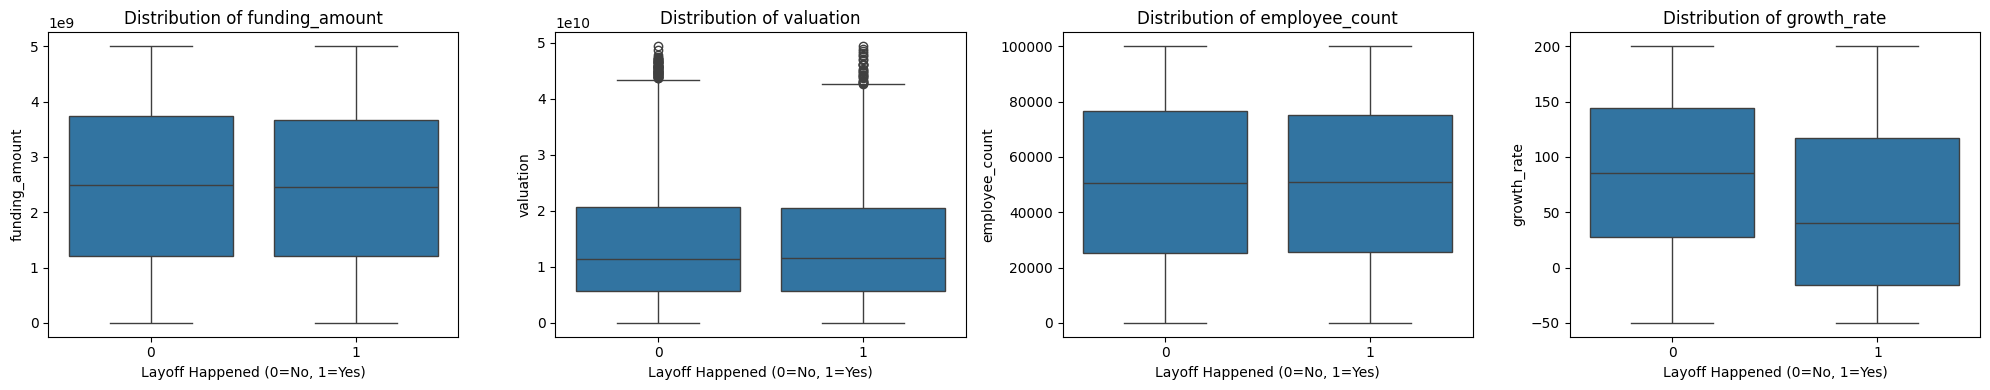

In [76]:
# code for boxplot distrib of each feature. KDE plots below offer much easier visualization to interp
import seaborn as sns

features = ["funding_amount", "valuation", "employee_count", "growth_rate"]

fig, axes = plt.subplots(1,4, figsize=(20, 4))

for i, feature in enumerate(features):

    sns.boxplot(data=train_df, x="layoff_happened", y=feature, ax=axes[i])
    
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel("Layoff Happened (0=No, 1=Yes)")
    
plt.tight_layout()
plt.show()

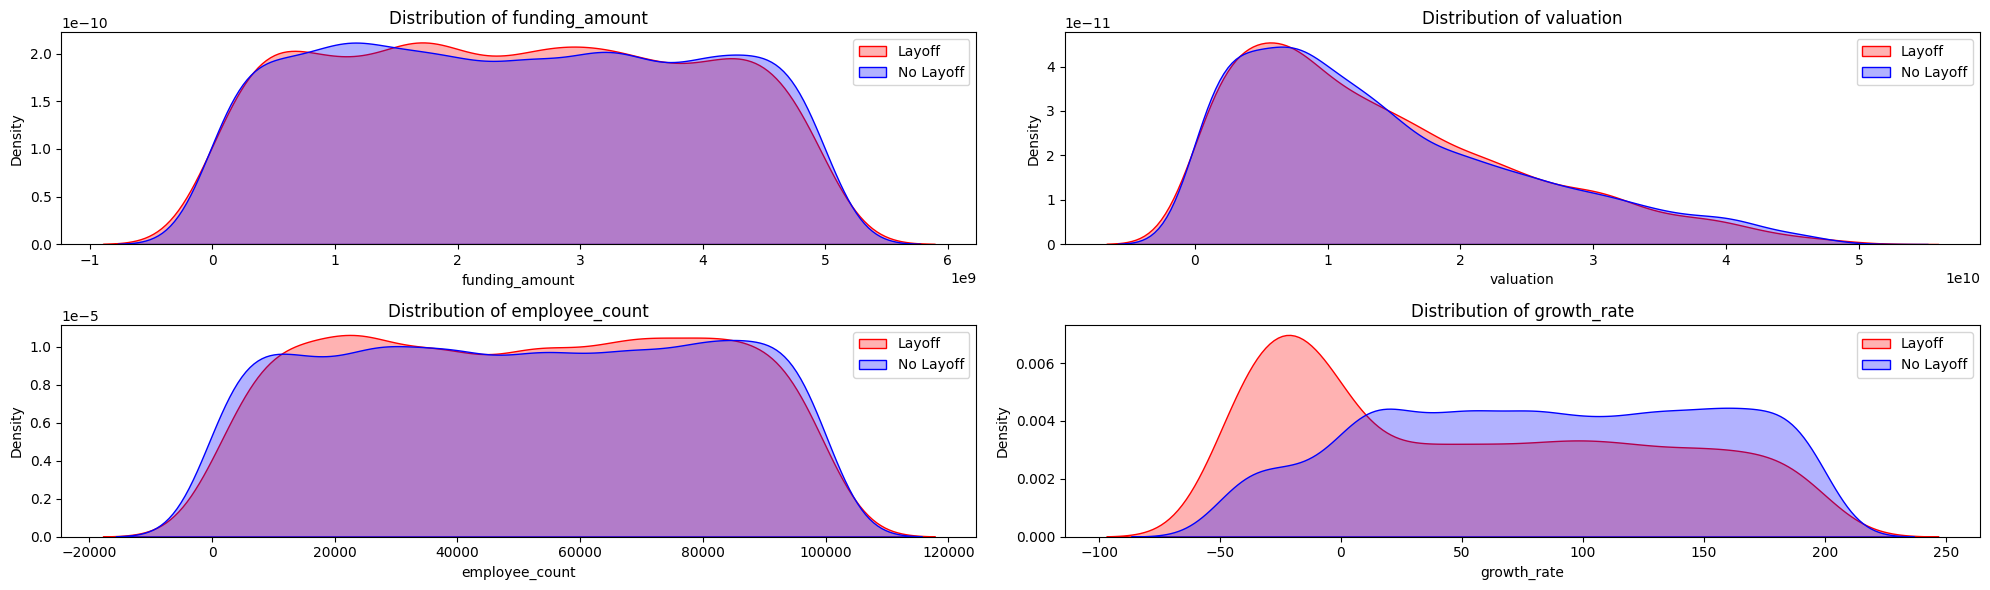

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(20, 6))

for i, col in enumerate(features):
    ax = axes[i // 2][i % 2]
    sns.kdeplot(data=laidoff_df, x=col, ax=ax, label="Layoff", color="red", fill=True, alpha=0.3)
    sns.kdeplot(data=not_laidoff_df, x=col, ax=ax, label="No Layoff", color="blue", fill=True, alpha=0.3)
    ax.set_title(f"Distribution of {col}")
    ax.legend()

plt.tight_layout()
plt.show()

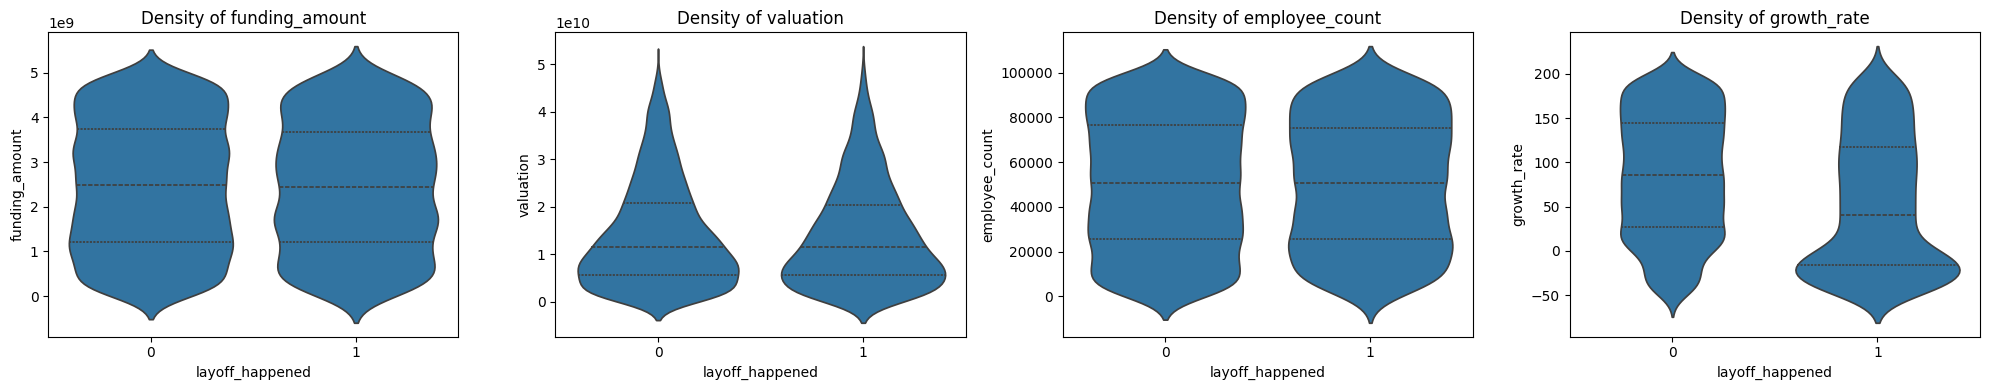

In [78]:
fig, axes = plt.subplots(1,4, figsize=(20,4))

for i, feature in enumerate(features):   

    sns.violinplot(data=train_df, x="layoff_happened", y=feature, ax=axes[i], inner="quartile")

    axes[i].set_title(f"Density of {feature}")

plt.tight_layout()
plt.show()

Inspecting our training data, we can see that between the firms that had layoffs and those that did not, only `growth_rate` appears to have a significantly different distribution. The other features behave identically between groups

$\quad\therefore\quad$ probably going to focus on growth rate as the main predictor of layoffs.

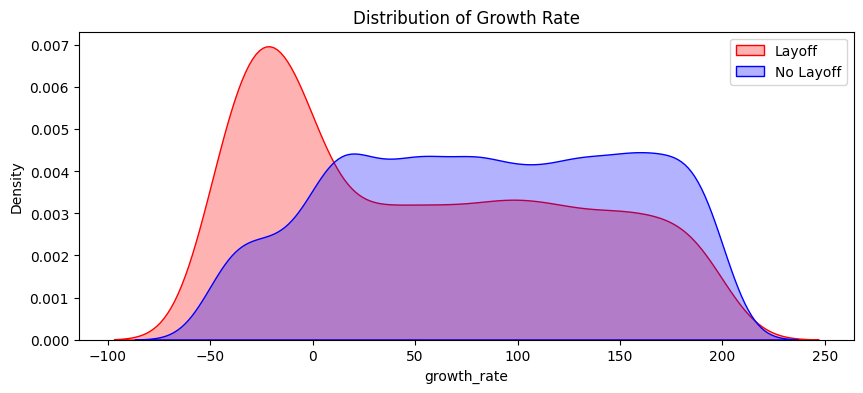

In [79]:
fig, ax = plt.subplots(figsize=(10, 4))

col = features[3]
sns.kdeplot(data=laidoff_df, x=col, ax=ax, label="Layoff", color="red", fill=True, alpha=0.3)
sns.kdeplot(data=not_laidoff_df, x=col, ax=ax, label="No Layoff", color="blue", fill=True, alpha=0.3)
ax.set_title("Distribution of Growth Rate")
ax.legend()

plt.show()